In [ ]:
import perceval as pcvl
import numpy as np
import math

phi1 = np.pi / 4
phi2 = np.pi / 2

mzi = pcvl.Circuit(2)
mzi.add((0, 1), pcvl.BS())             # BS thứ nhất
mzi.add(0, pcvl.PS(phi1))              # PS1 trên mode 0
mzi.add((0, 1), pcvl.BS())             # BS thứ hai
mzi.add(0, pcvl.PS(phi2))              # PS2 trên mode 0

# Xác định trạng thái đầu vào: 1 photon ở mode 0, 0 photon ở mode 1
input_state = pcvl.BasicState([1, 0])

# ==========================================
# PHẦN 1: TÍNH TOÁN LÝ THUYẾT (SIMULATOR)
# ==========================================
# Sử dụng backend 'Naive' hoặc 'SLOS' của Perceval để giả lập lý tưởng
processor_ideal = pcvl.Processor("Naive", mzi)
processor_ideal.with_input(input_state)

# Lấy mẫu 1000 shots
sampler_ideal = pcvl.algorithm.Sampler(processor_ideal)
ideal_counts = sampler_ideal.sample_count(1000)

print("Kết quả lý thuyết (Lý tưởng):", ideal_counts['results'])

# ==========================================
# PHẦN 2: CHẠY THỰC NGHIỆM TRÊN QPU BELENOS
# ==========================================

token = "_T_eyJhbGciOiJIUzUxMiIsInR5cCI6IkpXVCJ9.eyJpZCI6MjI0MSwiZXhwIjoxNzg1NzM5MjY2LjYyMjkyMDN9.ZdSxfp1hLOvT2D3nH8r71X7xhOBkgDwt-Tx4181i9WyB39-rDeyVLserD6KIFjN1B9kbX3rgngVCwaupKjdH8g" 

try:
    # 1. Kết nối với QPU 
    processor_qpu = pcvl.RemoteProcessor("qpu:belenos", token)
    processor_qpu.min_detected_photons_filter(1)
    
    processor_qpu.set_circuit(mzi)
    processor_qpu.with_input(input_state)
    
    # 2. CHÈN max_shots_per_call VÀO ĐÂY (Trong hàm Sampler)
    sampler_qpu = pcvl.algorithm.Sampler(processor_qpu, max_shots_per_call=1000)
    
    # Lấy mẫu 1000 shots
    qpu_counts = sampler_qpu.sample_count(1000)
    
    print("Kết quả thực nghiệm (QPU Belenos):", qpu_counts['results'])

# ==========================================
    # PHẦN 3: TÍNH TOÁN SAI SỐ (TVD)
    # ==========================================
    # Ép kiểu BSCount về tiêu chuẩn Dictionary của Python
    ideal_dict = dict(ideal_counts['results'])
    qpu_dict = dict(qpu_counts['results'])

    requested_shots = 1000
    expected_photons = 1
    
    all_states = set(ideal_dict.keys()).union(set(qpu_dict.keys()))
    tvd = 0
    
    # Lấy 1000 shots, nhưng ở QPU có thể bị hao hụt (photon loss)
    # Nên lấy tổng số count thực tế để tính xác suất chính xác nhất
    total_shots_ideal = sum(ideal_dict.values())
    total_shots_qpu = sum(qpu_dict.values())
    
    for state in all_states:
        p_ideal = ideal_dict.get(state, 0) / total_shots_ideal
        p_qpu = qpu_dict.get(state, 0) / total_shots_qpu
        tvd += abs(p_ideal - p_qpu)
        
    tvd = 0.5 * tvd
    
    print(f"\nSai số Khoảng cách biến thiên tổng (TVD) = {tvd:.4f}")
    print(f"Độ chính xác tương đối = {(1 - tvd) * 100:.2f}%")

    valid_shots = 0
    multi_photon_shots = 0
    zero_photon_shots = 0
    
    for state, count in qpu_dict.items():
        # Lấy tổng số photon trong trạng thái hiện tại (ví dụ |1,0> là 1, |0,2> là 2)
        photons_in_state = sum(state) 
        
        if photons_in_state == expected_photons:
            valid_shots += count
        elif photons_in_state > expected_photons:
            multi_photon_shots += count
        elif photons_in_state < expected_photons:
            zero_photon_shots += count
            
    # Tính số shot bị mất hoàn toàn (QPU trả về ít count hơn so với 1000 yêu cầu ban đầu)
    total_returned_shots = sum(qpu_dict.values())
    unaccounted_shots = requested_shots - total_returned_shots
    total_lost_shots = unaccounted_shots + zero_photon_shots
    
    loss_rate = (total_lost_shots / requested_shots) * 100
    multi_photon_rate = (multi_photon_shots / requested_shots) * 100
    
    print("\n--- 1. PHÂN TÍCH LỖI VẬT LÝ ---")
    print(f"Tổng số shots yêu cầu: {requested_shots}")
    print(f"Tổng số shots QPU trả về: {total_returned_shots}")
    print(f"Số shots hợp lệ (đúng {expected_photons} photon): {valid_shots}")
    print(f"Lỗi suy hao photon: {total_lost_shots} shots ({loss_rate:.2f}%)")
    print(f"Lỗi phát đa photon: {multi_photon_shots} shots ({multi_photon_rate:.2f}%)")

    # ---------------------------------------------------------
    # 3.2 TÍNH TOÁN TVD VÀ FIDELITY (TRÊN DỮ LIỆU HỢP LỆ)
    # ---------------------------------------------------------
    # Tính tổng shot hợp lệ của lý thuyết (thường không có suy hao)
    valid_shots_ideal = sum([count for state, count in ideal_dict.items() if sum(state) == expected_photons])
    
    tvd = 0
    fidelity = 0
    all_states = set(ideal_dict.keys()).union(set(qpu_dict.keys()))
    
    for state in all_states:
        # Hậu chọn lọc (Post-selection): Chỉ tính toán trên các trạng thái có đúng số photon kỳ vọng
        if sum(state) == expected_photons:
            p_ideal = ideal_dict.get(state, 0) / valid_shots_ideal if valid_shots_ideal > 0 else 0
            p_qpu = qpu_dict.get(state, 0) / valid_shots if valid_shots > 0 else 0
            
            # Cộng dồn công thức TVD
            tvd += abs(p_ideal - p_qpu)
            
            # Cộng dồn công thức Fidelity
            fidelity += math.sqrt(p_ideal * p_qpu)
            
    tvd = 0.5 * tvd
    fidelity = fidelity ** 2
    
    print("\n--- 2. PHÂN TÍCH THỐNG KÊ (HẬU CHỌN LỌC) ---")
    print(f"Sai số tổng thể (TVD): {tvd:.4f}")
    print(f"Độ trung thực lượng tử (Fidelity): {fidelity:.4f} ({fidelity*100:.2f}%)")

except Exception as e:
    print("\nLỗi:", e)

Kết quả lý thuyết (Lý tưởng): {
  |1,0>: 156
  |0,1>: 844
}
Kết quả thực nghiệm (QPU Belenos): {
  |1,0>: 43
  |0,1>: 957
}

Sai số Khoảng cách biến thiên tổng (TVD) = 0.1130
Độ chính xác tương đối = 88.70%

--- 1. PHÂN TÍCH LỖI VẬT LÝ ---
Tổng số shots yêu cầu: 1000
Tổng số shots QPU trả về: 1000
Số shots hợp lệ (đúng 1 photon): 1000
Lỗi suy hao photon: 0 shots (0.00%)
Lỗi phát đa photon: 0 shots (0.00%)

--- 2. PHÂN TÍCH THỐNG KÊ (HẬU CHỌN LỌC) ---
Sai số tổng thể (TVD): 0.1130
Độ trung thực lượng tử (Fidelity): 0.9616 (96.16%)


In [ ]:
import perceval as pcvl
import numpy as np
import math

# ==========================================
# PHẦN 1: KHỞI TẠO MẠCH 
# ==========================================
# Sử dụng Heralded CNOT tích hợp sẵn của Perceval 
# Processor này đã tự động xử lý các photon trợ lực (heralds) bên trong.
cnot_processor = pcvl.catalog["heralded cnot"].build_processor()


# Xác định trạng thái đầu vào (Mã hóa Dual-rail 4 modes dữ liệu):
# Qubit 1 (Control) ở mode 0,1. Đặt là |1> => [0, 1]
# Qubit 2 (Target) ở mode 2,3. Đặt là |0> => [1, 0]
# Tổng hợp đầu vào: [0, 1, 1, 0] (Sẽ có chính xác 2 photon)
input_state = pcvl.BasicState([0, 1, 1, 0])

# ==========================================
# PHẦN 2: CHẠY LÝ THUYẾT & QPU
# ==========================================
# 2.1 Chạy Lý thuyết (Simulator)
cnot_processor.with_input(input_state)
sampler_ideal = pcvl.algorithm.Sampler(cnot_processor)
ideal_counts = sampler_ideal.sample_count(1000)

print("Kết quả lý thuyết (Lý tưởng):", ideal_counts['results'])

# 2.2 Chạy Thực nghiệm trên QPU
token = "_T_eyJhbGciOiJIUzUxMiIsInR5cCI6IkpXVCJ9.eyJpZCI6MjI0MSwiZXhwIjoxNzg1NzM5MjY2LjYyMjkyMDN9.ZdSxfp1hLOvT2D3nH8r71X7xhOBkgDwt-Tx4181i9WyB39-rDeyVLserD6KIFjN1B9kbX3rgngVCwaupKjdH8g" 

try:
    # Lấy circuit lõi từ processor để nạp vào QPU Belenos
    core_circuit = cnot_processor.linear_circuit()
    
    processor_qpu = pcvl.RemoteProcessor("qpu:belenos", token)
    processor_qpu.min_detected_photons_filter(1)
    processor_qpu.set_circuit(core_circuit)
    
    # Phải truyền input có chứa cả photon herald (2 dữ liệu + 2 herald = 4 photon)
    # Heralded CNOT chuẩn cần photon ở mode 4 và 5 để kích hoạt
    full_qpu_input = pcvl.BasicState([0, 1, 1, 0, 1, 1]) 
    processor_qpu.with_input(full_qpu_input)
    
    sampler_qpu = pcvl.algorithm.Sampler(processor_qpu, max_shots_per_call=1000)
    qpu_counts = sampler_qpu.sample_count(1000)
    
    print("Kết quả thực nghiệm (QPU Belenos):", qpu_counts['results'])

    # ==========================================
    # PHẦN 3: PHÂN TÍCH SAI SỐ CHI TIẾT
    # ==========================================
    ideal_dict = dict(ideal_counts['results'])
    qpu_dict = dict(qpu_counts['results'])
    
    requested_shots = 1000
    
    # QUAN TRỌNG: Mạch 2 Qubits nên kỳ vọng đầu ra có 2 photon (không tính herald)
    expected_photons = 2 
    
    valid_shots = 0
    multi_photon_shots = 0
    zero_photon_shots = 0
    
    for state, count in qpu_dict.items():
        # Chỉ xét 4 mode đầu tiên (dữ liệu), bỏ qua mode herald nếu có
        data_state = state[:4] 
        photons_in_state = sum(data_state) 
        
        if photons_in_state == expected_photons:
            valid_shots += count
        elif photons_in_state > expected_photons:
            multi_photon_shots += count
        elif photons_in_state < expected_photons:
            zero_photon_shots += count
            
    total_returned_shots = sum(qpu_dict.values())
    unaccounted_shots = requested_shots - total_returned_shots
    total_lost_shots = unaccounted_shots + zero_photon_shots
    
    loss_rate = (total_lost_shots / requested_shots) * 100
    multi_photon_rate = (multi_photon_shots / requested_shots) * 100
    
    print("\n--- 1. PHÂN TÍCH LỖI VẬT LÝ ---")
    print(f"Tổng số shots yêu cầu: {requested_shots}")
    print(f"Tổng số shots QPU trả về: {total_returned_shots}")
    print(f"Số shots hợp lệ (đúng {expected_photons} photon dữ liệu): {valid_shots}")
    print(f"Lỗi suy hao photon: {total_lost_shots} shots ({loss_rate:.2f}%)")
    print(f"Lỗi phát đa photon: {multi_photon_shots} shots ({multi_photon_rate:.2f}%)")

    # ---------------------------------------------------------
    # TÍNH TOÁN TVD VÀ FIDELITY (TRÊN DỮ LIỆU HỢP LỆ)
    # ---------------------------------------------------------
    valid_shots_ideal = sum([count for state, count in ideal_dict.items() if sum(state[:4]) == expected_photons])
    
    tvd = 0
    fidelity = 0
    
    # Chuẩn hóa keys để so sánh (chỉ lấy 4 modes dữ liệu)
    ideal_states_4modes = {state[:4]: count for state, count in ideal_dict.items()}
    qpu_states_4modes = {}
    for state, count in qpu_dict.items():
        st = state[:4]
        qpu_states_4modes[st] = qpu_states_4modes.get(st, 0) + count

    all_states = set(ideal_states_4modes.keys()).union(set(qpu_states_4modes.keys()))
    
    for state in all_states:
        if sum(state) == expected_photons:
            p_ideal = ideal_states_4modes.get(state, 0) / valid_shots_ideal if valid_shots_ideal > 0 else 0
            p_qpu = qpu_states_4modes.get(state, 0) / valid_shots if valid_shots > 0 else 0
            
            tvd += abs(p_ideal - p_qpu)
            fidelity += math.sqrt(p_ideal * p_qpu)
            
    tvd = 0.5 * tvd
    fidelity = fidelity ** 2
    
    print("\n--- 2. PHÂN TÍCH THỐNG KÊ (HẬU CHỌN LỌC) ---")
    print(f"Sai số tổng thể (TVD): {tvd:.4f}")
    print(f"Độ trung thực lượng tử (Fidelity): {fidelity:.4f} ({fidelity*100:.2f}%)")
    print(f"Độ chính xác tương đối = {(1 - tvd) * 100:.2f}%")

except Exception as e:
    print("\nLỗi:", e)

Kết quả lý thuyết (Lý tưởng): {
  |0,1,0,1>: 1000
}
Kết quả thực nghiệm (QPU Belenos): {
  |0,0,2,0,0,0>: 1
  |0,0,0,1,0,1>: 1
  |0,0,0,0,0,2>: 1
  |0,0,1,0,0,1>: 2
  |1,1,0,0,0,0>: 2
  |0,1,0,0,0,1>: 3
  |0,0,0,0,1,0>: 314
  |0,0,1,1,0,0>: 3
  |0,0,1,0,1,0>: 6
  |0,0,0,0,0,1>: 58
  |1,0,0,0,0,0>: 15
  |0,0,0,1,1,0>: 8
  |0,2,0,0,0,0>: 12
  |0,1,1,0,0,0>: 4
  |0,1,0,0,0,0>: 241
  |0,0,1,0,0,0>: 91
  |0,0,0,0,2,0>: 11
  |0,0,0,1,0,0>: 198
  |0,1,0,1,0,0>: 7
  |0,0,0,0,1,1>: 2
  |0,1,0,0,1,0>: 10
  |0,0,0,2,0,0>: 10
}

--- 1. PHÂN TÍCH LỖI VẬT LÝ ---
Tổng số shots yêu cầu: 1000
Tổng số shots QPU trả về: 1000
Số shots hợp lệ (đúng 2 photon dữ liệu): 39
Lỗi suy hao photon: 961 shots (96.10%)
Lỗi phát đa photon: 0 shots (0.00%)

--- 2. PHÂN TÍCH THỐNG KÊ (HẬU CHỌN LỌC) ---
Sai số tổng thể (TVD): 0.8205
Độ trung thực lượng tử (Fidelity): 0.1795 (17.95%)
Độ chính xác tương đối = 17.95%


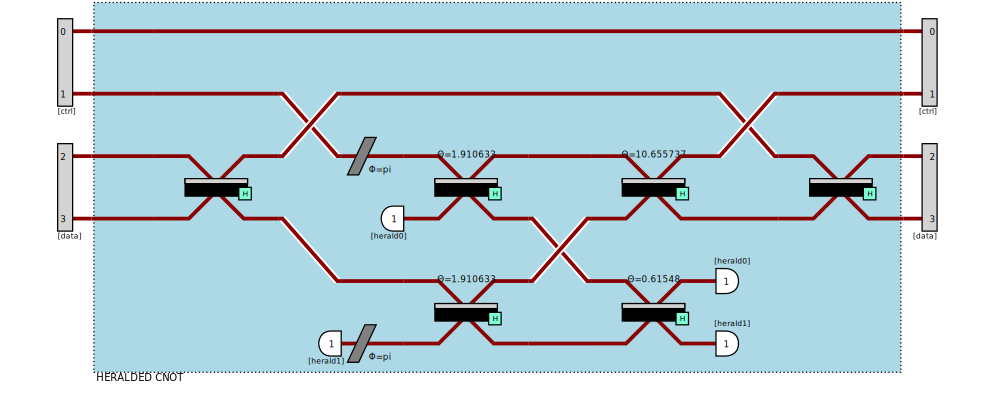

In [45]:

cnot_gate = pcvl.catalog["heralded cnot"].build_processor()  

pcvl.pdisplay(cnot_gate, recursive=True)

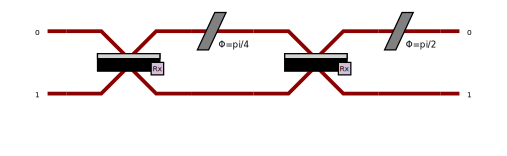

In [46]:
mzi = pcvl.Circuit(2)
mzi.add((0, 1), pcvl.BS())             # BS thứ nhất
mzi.add(0, pcvl.PS(phi1))              # PS1 trên mode 0
mzi.add((0, 1), pcvl.BS())             # BS thứ hai
mzi.add(0, pcvl.PS(phi2))              # PS2 trên mode 0

pcvl.pdisplay(mzi, recursive=True)

In [57]:
def plot_quantum_results(ax, ideal_dict, qpu_dict, title, ideal_state=None, is_cnot=False, fixed_slots=None):
    total_ideal = sum(ideal_dict.values())
    total_qpu = 1000 if is_cnot else sum(qpu_dict.values())

    all_states = list(set(ideal_dict.keys()).union(set(qpu_dict.keys())))

    if ideal_state is not None:
        all_states.sort(key=lambda x: (x != ideal_state, x))
    else:
        all_states.sort()

    ideal_probs = [(ideal_dict.get(st, 0) / total_ideal) * 100 for st in all_states]
    qpu_probs = [(qpu_dict.get(st, 0) / total_qpu) * 100 for st in all_states]

    n_states = len(all_states)

    # Ép cả 2 plots dùng cùng số ô trên trục x
    if fixed_slots is None:
        fixed_slots = n_states

    # Căn giữa các state nếu plot có ít state hơn
    start = (fixed_slots - n_states) / 2
    x = np.arange(n_states) + start

    width = 0.35

    bars1 = ax.bar(
        x - width / 2,
        ideal_probs,
        width,
        label='Theory (Ideal)',
        color="#44A5FA",
        edgecolor='black'
    )

    bars2 = ax.bar(
        x + width / 2,
        qpu_probs,
        width,
        label='Experiment (Belenos)',
        color="#ca0000",
        edgecolor='black'
    )

    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel('Probability (%)', fontsize=11, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(all_states, rotation=25, ha="right", fontsize=9)

    # Quan trọng: ép giới hạn trục x giống nhau cho cả 2 plots
    ax.set_xlim(-0.5, fixed_slots - 0.5)

    ax.set_ylim(0, 110)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.legend(fontsize=10, loc='upper right')

    for bar, prob in zip(bars1, ideal_probs):
        if prob > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                prob + 2,
                f'{prob:.1f}%',
                ha='center',
                va='bottom',
                fontsize=8,
                color='#1f77b4'
            )

    for bar, prob in zip(bars2, qpu_probs):
        if prob > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                prob + 2,
                f'{prob:.1f}%',
                ha='center',
                va='bottom',
                fontsize=8,
                color='#d62728'
            )

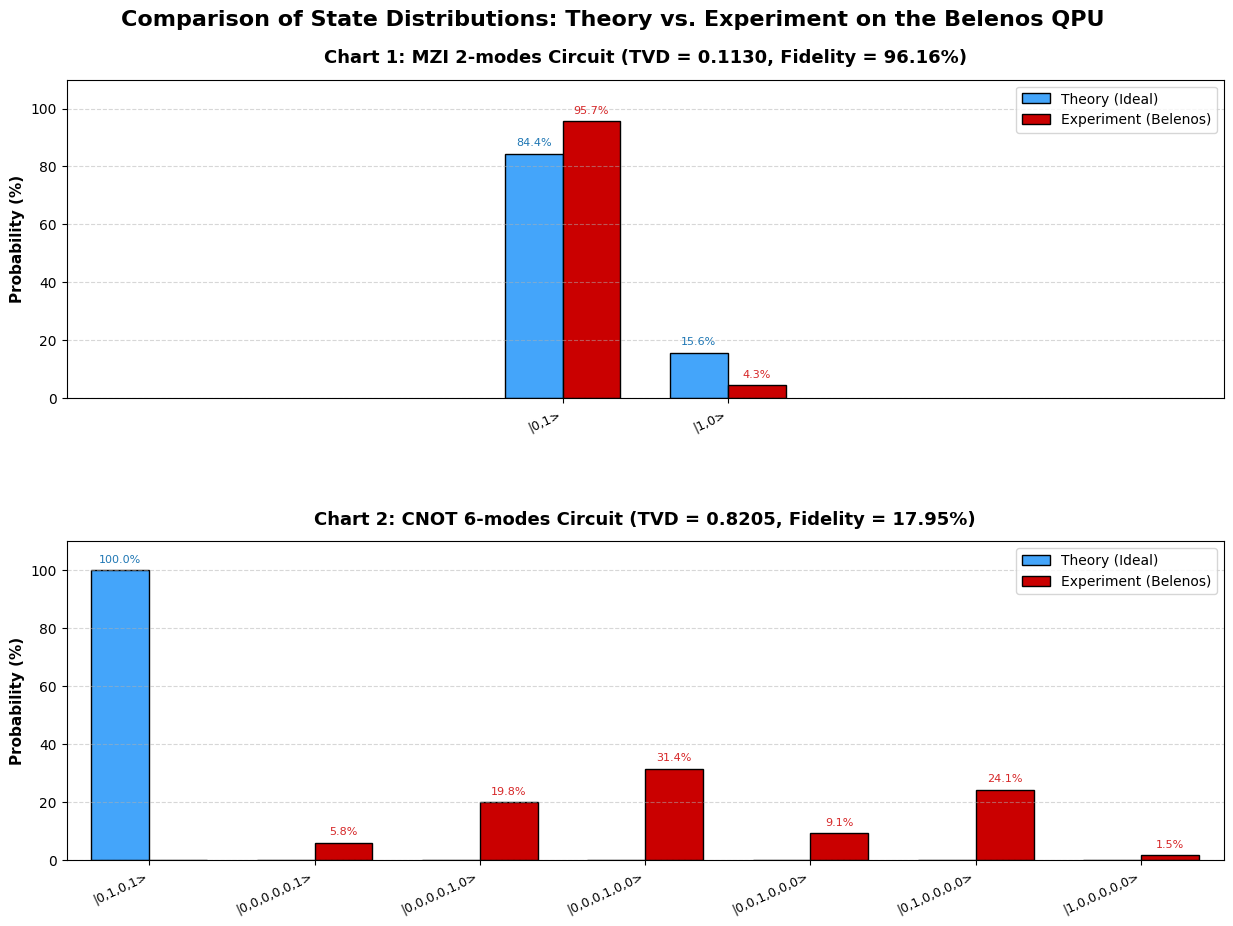

In [60]:
fig = plt.figure(figsize=(13, 10))

gs = fig.add_gridspec(
    2, 1,
    height_ratios=[1, 1],
    hspace=0.45
)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

fixed_slots = 7

plot_quantum_results(
    ax1,
    mzi_ideal_counts,
    mzi_qpu_counts,
    "Chart 1: MZI 2-modes Circuit (TVD = 0.1130, Fidelity = 96.16%)",
    fixed_slots=fixed_slots
)

plot_quantum_results(
    ax2,
    cnot_ideal_counts,
    cnot_qpu_counts,
    "Chart 2: CNOT 6-modes Circuit (TVD = 0.8205, Fidelity = 17.95%)",
    ideal_state='|0,1,0,1>',
    is_cnot=True,
    fixed_slots=fixed_slots
)

fig.suptitle(
    "Comparison of State Distributions: Theory vs. Experiment on the Belenos QPU",
    fontsize=16,
    fontweight='bold',
    y=0.97
)

fig.subplots_adjust(
    top=0.90,
    bottom=0.12,
    left=0.08,
    right=0.97
)

plt.savefig("Bao_cao_QPU_Belenos_balanced.png", dpi=600, bbox_inches='tight')
plt.show()

In [64]:
import os

print("File được lưu tại:")
print(os.path.abspath("Bao_cao_QPU_Belenos_balanced.png"))

File được lưu tại:
c:\Users\kiem\AppData\Local\Programs\Microsoft VS Code\Bao_cao_QPU_Belenos_balanced.png
